In [11]:
import os
import numpy as np
import librosa
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from skimage.transform import resize

In [12]:
DATA_ROOT = "data/gtzan/genres_original/"
SR = 22050
SEGMENT_DURATION = 3
IMG_SIZE = (128,128)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

In [13]:
genres = sorted(os.listdir(DATA_ROOT))
genre_to_index = {g:i for i,g in enumerate(genres)}

filepaths = []
labels = []

for genre in genres:
    genre_folder = os.path.join(DATA_ROOT, genre)
    for file in os.listdir(genre_folder):
        if file.endswith(".wav"):
            filepaths.append(os.path.join(genre_folder, file))
            labels.append(genre_to_index[genre])

filepaths = np.array(filepaths)
labels = np.array(labels)

In [14]:
X_train, X_temp, y_train, y_temp = train_test_split(
    filepaths, labels, test_size=0.3, stratify=labels, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

In [15]:
def wav_to_segments(path, label):

    segments = []
    labels_out = []
    path = path.numpy().decode("utf-8")

    try:
        y, sr = librosa.load(path, sr=SR)
    except Exception:
        return np.zeros((0,128,128), dtype=np.float32), np.zeros((0,), dtype=np.int64)

    samples_per_segment = SR * SEGMENT_DURATION
    num_segments = int(len(y) // samples_per_segment)

    for i in range(num_segments):

        start = i * samples_per_segment
        end = start + samples_per_segment

        segment = y[start:end]

        if len(segment) < samples_per_segment:
            continue

        try:
            mel = librosa.feature.melspectrogram(
                y=segment,
                sr=sr,
                n_mels=128,
                n_fft=1024,
                hop_length=512
            )

            mel_db = librosa.power_to_db(mel, ref=np.max)

            mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-6)

            mel_resized = resize(
                mel_db,
                IMG_SIZE,
                mode="reflect",
                anti_aliasing=True
            )

            segments.append(mel_resized.astype(np.float32))
            labels_out.append(label.numpy())

        except Exception:
            # skip segment if mel computation fails
            continue

    if len(segments) == 0:
        return np.empty((0,128,128), dtype=np.float32), np.empty((0,), dtype=np.int64)

    return np.array(segments), np.array(labels_out)

In [16]:
def create_dataset(paths, labels):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    def process(path, label):
        segs, labs = tf.py_function(
            wav_to_segments,
            [path, label],
            [tf.float32, tf.int64]
        )

        segs.set_shape([None, 128, 128])
        labs.set_shape([None])

        segs = tf.expand_dims(segs, -1)

        return tf.data.Dataset.from_tensor_slices((segs, labs))

    ds = ds.flat_map(process)
    ds = ds.shuffle(2000)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

    return ds

train_ds = create_dataset(X_train, y_train)
val_ds   = create_dataset(X_val, y_val)
test_ds  = create_dataset(X_test, y_test)

In [17]:
def build_model():
    inputs = tf.keras.layers.Input(shape=(128,128,1))

    x = tf.keras.layers.Conv2D(32,3,padding='same',activation='relu')(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPool2D()(x)
    x = tf.keras.layers.Dropout(0.2)(x)

    x = tf.keras.layers.Conv2D(64,3,padding='same',activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPool2D()(x)
    x = tf.keras.layers.Dropout(0.25)(x)

    x = tf.keras.layers.Conv2D(128,3,padding='same',activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPool2D()(x)
    x = tf.keras.layers.Dropout(0.3)(x)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.4)(x)

    outputs = tf.keras.layers.Dense(10, activation='softmax')(x)

    return tf.keras.Model(inputs, outputs)

model = build_model()
model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 128, 128, 1)]     0         
                                                                 
 conv2d_3 (Conv2D)           (None, 128, 128, 32)      320       
                                                                 
 batch_normalization_3 (Batc  (None, 128, 128, 32)     128       
 hNormalization)                                                 
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 64, 64, 32)       0         
 2D)                                                             
                                                                 
 dropout_4 (Dropout)         (None, 64, 64, 32)        0         
                                                                 
 conv2d_4 (Conv2D)           (None, 64, 64, 64)        1849

In [18]:
logdir = "logs/gtzan/run1"
tb_cb = tf.keras.callbacks.TensorBoard(logdir)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[tb_cb, tf.keras.callbacks.EarlyStopping(patience=7)]
)

Epoch 1/10


     23/Unknown - 16s 327ms/step - loss: 1.9870 - accuracy: 0.2880

C:\Users\nisan\AppData\Local\Temp\ipykernel_23540\989672829.py:8: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=SR)
c:\Program Files\Python310\lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


219/219 [==============================] - 160s 697ms/step - loss: 1.5000 - accuracy: 0.4580 - val_loss: 9.3869 - val_accuracy: 0.1000
Epoch 2/10
219/219 [==============================] - 144s 526ms/step - loss: 1.1451 - accuracy: 0.5968 - val_loss: 6.5860 - val_accuracy: 0.1947
Epoch 3/10
219/219 [==============================] - 152s 657ms/step - loss: 0.9425 - accuracy: 0.6731 - val_loss: 4.4315 - val_accuracy: 0.2007
Epoch 4/10
219/219 [==============================] - 89s 370ms/step - loss: 0.8169 - accuracy: 0.7139 - val_loss: 1.7955 - val_accuracy: 0.4767
Epoch 5/10
219/219 [==============================] - 91s 378ms/step - loss: 0.7308 - accuracy: 0.7480 - val_loss: 2.4027 - val_accuracy: 0.4307
Epoch 6/10
219/219 [==============================] - 88s 367ms/step - loss: 0.6309 - accuracy: 0.7773 - val_loss: 1.2998 - val_accuracy: 0.5747
Epoch 7/10
219/219 [==============================] - 90s 373ms/step - loss: 0.5930 - accuracy: 0.7926 - val_loss: 2.2620 - val_accuracy: 

1/1 [==============================] - 0s 127ms/step


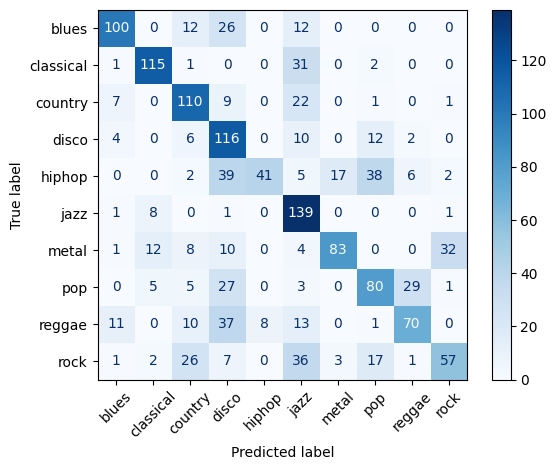

In [19]:
y_true, y_pred = [], []

for x,y in test_ds:
    preds = model.predict(x)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(y.numpy())

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=genres)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.show()